In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

file_path = '/content/drive/My Drive/Zahra/Year_403.xlsx'
df = pd.read_excel(file_path)
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Value added insurance premium  Received from the driver  Scale fee  \
0                         144000                  12669000          0   
1                         144000                  12669000          0   
2                         144000                  12704000          0   
3                         144000                  12704000          0   
4                          81000                    647500          0   

   Evacuation fee  added value  Complications of moving goods  \
0               0            0                        5616000   
1               0            0                        5616000   
2               0            0                        5634000   
3               0            0                        5634000   
4               0            0                        1665000   

  Bill of lading registration time Tracki

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601217 entries, 0 to 601216
Data columns (total 43 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   Value added insurance premium     601217 non-null  int64  
 1   Received from the driver          601217 non-null  int64  
 2   Scale fee                         601217 non-null  int64  
 3   Evacuation fee                    601217 non-null  int64  
 4   added value                       601217 non-null  int64  
 5   Complications of moving goods     601217 non-null  int64  
 6   Bill of lading registration time  601217 non-null  object 
 7   Tracking code watch               601217 non-null  object 
 8   date of interception              601217 non-null  object 
 9   Company commission                601217 non-null  int64  
 10  Insurance amount                  601217 non-null  int64  
 11  Loading fee                       601217 non-null  i

In [ ]:
df.shape

(601217, 43)

In [ ]:
import pandas as pd
info_df = pd.read_excel('/content/drive/MyDrive/Zahra/loader_Capacity_lookup.xlsx')

In [ ]:
merged_df = pd.merge(df, info_df, left_on='Loader code', right_on='Loadercode', how='left')

In [ ]:
print(merged_df.columns)

Index(['Value added insurance premium', 'Received from the driver',
       'Scale fee', 'Evacuation fee', 'added value',
       'Complications of moving goods', 'Bill of lading registration time',
       'Tracking code watch', 'date of interception', 'Company commission',
       'Insurance amount', 'Loading fee', 'Total fare',
       'Recipient is national ID', 'Sender is national ID',
       'Postal code of recipient', 'Postal code of the sender', 'interception',
       'Device smart card', 'Driver smart card', 'Packaging code',
       'License plate code', 'Serial code', 'License plate number',
       'Unnamed: 24', 'Delivery date', 'Date of issue', 'Loader code',
       'The name of the destination city', 'Destination city code',
       'Name of the city of orgin', 'Code of the city of orgin',
       'product name', 'product code', 'distance', 'weight',
       'Calculation fare', 'rent', 'Bill of lading number',
       'Bill of lading series', 'Company name', 'Company Code', 'year',

In [ ]:
merged_df['Capacity_ton'].value_counts()

,count
Capacity_ton,
4<= GVW <7,146761
22<= CVW,134114
17<= GVW <20,75426
7<= GVW <10,72129
20<= GVW,28781
<4 GVW,5255
10<= GVW <13,4722
13<= GVW <17,4330


In [ ]:
filtered_df = merged_df[merged_df['Capacity_ton'] == '<4 GVW']

الان یه جدول داریم شامل همه‌ی ردیف‌هایی که کد بارگیر
 اون‌ها به ظرفیت کمتر از 4 تن نگاشت شده

In [ ]:
filtered_df.shape

(5255, 46)

In [ ]:
filtered_df.head()

,Value added insurance premium,Received from the driver,Scale fee,Evacuation fee,added value,Complications of moving goods,Bill of lading registration time,Tracking code watch,date of interception,Company commission,...,Calculation fare,rent,Bill of lading number,Bill of lading series,Company name,Company Code,year,ID,Capacity_ton,Loadercode
4,81000,647500,0,0,0,1665000,13:28,13:33,1403/01/05,1480000,...,18500000,18500000,3680279,1402/14,خليج فارس (تهران ),111100459,1403,1.0,<4 GVW,631.0
788,135,66000,0,0,0,396000,17:50,17:50,1402/12/29,44000,...,4400000,4400000,1898962,1402/14,چابکسوار بوستان,141400031,1403,1.0,<4 GVW,632.0
789,135,420000,0,0,0,2520000,21:17,21:20,1402/12/29,280000,...,28000000,28000000,1898967,1402/14,چابکسوار بوستان,141400031,1403,1.0,<4 GVW,632.0
1170,18225,91500,0,1464000,0,1647000,16:44,16:45,1402/12/29,366000,...,18300000,18300000,4709165,1402/14,امان بار قم,141400037,1403,1.0,<4 GVW,608.0
1306,424170,16250000,0,0,0,1170000,11:02,11:02,1402/12/29,650000,...,13000000,13000000,1511302,1402/14,قصربار قم,141400046,1403,1.0,<4 GVW,706.0


روش آماری ساده برای تشخیص  ناهنجاری
این روش بر اساس قانون سه‌سیگما


In [ ]:
mean_fare = filtered_df['Calculation fare'].mean()
std_fare = filtered_df['Calculation fare'].std()

mean_insurance = filtered_df['Insurance amount'].mean()
std_insurance = filtered_df['Insurance amount'].std()

# فیلتر رکوردهایی که خارج از بازه [mean - 3*std, mean + 3*std] هستند → ناهنجار
fare_anomalies = filtered_df[
    (filtered_df['Calculation fare'] < mean_fare - 3 * std_fare) |
    (filtered_df['Calculation fare'] > mean_fare + 3 * std_fare)
]

insurance_anomalies = filtered_df[
    (filtered_df['Insurance amount'] < mean_insurance - 3 * std_insurance) |
    (filtered_df['Insurance amount'] > mean_insurance + 3 * std_insurance)
]
print("ناهنجاری در کرایه محاسباتی:")
print(fare_anomalies[['Bill of lading number', 'Calculation fare']])

print("\nناهنجاری در مبلغ بیمه:")
print(insurance_anomalies[['Bill of lading number', 'Insurance amount']])

ناهنجاری در کرایه محاسباتی:
        Bill of lading number  Calculation fare
16336                 1512475          90514925
18638                 3182271          81279000
38206                 1513924          90404770
38356                 6901596          82508535
38397                 6901534         147780501
...                       ...               ...
593860                7338650          82867580
593921                7338479          85022374
599858                2596507          82867580
599900                2593031         216921925
600039                2593034          88043263

[83 rows x 2 columns]

ناهنجاری در مبلغ بیمه:
        Bill of lading number  Insurance amount
18618                 3188967           9900000
48880                 6905627           8250000
48883                 6905626          11550000
48921                 6905623          11550000
50554                 5477668           8470000
67676                 7241314          19800000
89800        

In [ ]:
print("تعداد ناهنجاری کرایه:", fare_anomalies.shape[0])
print("تعداد ناهنجاری بیمه:", insurance_anomalies.shape[0])

تعداد ناهنجاری کرایه: 83
تعداد ناهنجاری بیمه: 39


In [ ]:
# استخراج شماره بارنامه‌ها از رکوردهای ناهنجار
bill_numbers = insurance_anomalies['Bill of lading number'].tolist()
print("🔸 تعداد بارنامه‌های ناهنجار:", len(bill_numbers))
print("🔹 چند مورد اول:", bill_numbers[:10])


🔸 تعداد بارنامه‌های ناهنجار: 39
🔹 چند مورد اول: [3188967, 6905627, 6905626, 6905623, 5477668, 7241314, 6906214, 6970193, 6970194, 1070889]


In [ ]:
# ذخیره شماره بارنامه‌ها در فایل اکسل
import pandas as pd
pd.DataFrame({'bill of lading number': bill_numbers}).to_excel('insurance_anomalies_bills.xlsx', index=False)


In [ ]:
insurance_anomalies.head(10)

,Value added insurance premium,Received from the driver,Scale fee,Evacuation fee,added value,Complications of moving goods,Bill of lading registration time,Tracking code watch,date of interception,Company commission,...,Calculation fare,rent,Bill of lading number,Bill of lading series,Company name,Company Code,year,ID,Capacity_ton,Loadercode
18618,900000,11525000,0,0,0,1170000,14:08,14:12,1403/01/21,455000,...,13000000,13000000,3188967,1402/14,کالاي شتابان شمال,161600461,1403,1.0,<4 GVW,631.0
48880,825000,1300000,0,0,0,1170000,19:17,19:17,1403/02/09,1300000,...,13000000,13000000,6905627,1402/14,قصربار قم,141400046,1403,1.0,<4 GVW,706.0
48883,1155000,1300000,0,0,0,1170000,18:53,18:54,1403/02/09,1300000,...,13000000,13000000,6905626,1402/14,قصربار قم,141400046,1403,1.0,<4 GVW,706.0
48921,1155000,1300000,0,0,0,1170000,17:16,17:16,1403/02/09,1300000,...,13000000,13000000,6905623,1402/14,قصربار قم,141400046,1403,1.0,<4 GVW,706.0
50554,770000,450000,0,0,0,1620000,14:28,14:31,1403/02/08,450000,...,18000000,18000000,5477668,1402/14,توحيد راه سلفچگان,141400051,1403,1.0,<4 GVW,608.0
67676,1800000,652500,0,0,0,2349000,15:13,15:17,1403/02/22,652500,...,26100000,26100000,7241314,1402/14,توحيد راه سلفچگان,141400051,1403,1.0,<4 GVW,608.0
89800,825000,1300000,0,0,0,1170000,15:20,15:23,1403/03/05,1300000,...,13000000,13000000,6906214,1402/14,قصربار قم,141400046,1403,1.0,<4 GVW,706.0
237699,990000,1700000,0,0,0,1530000,10:08,10:09,1403/06/08,1700000,...,17000000,17000000,6970193,1402/15,قصربار قم,141400046,1403,1.0,<4 GVW,706.0
237733,990000,1700000,0,0,0,1530000,11:09,11:09,1403/06/08,1700000,...,17000000,17000000,6970194,1402/15,قصربار قم,141400046,1403,1.0,<4 GVW,706.0
276545,990000,1700000,0,0,0,1530000,16:56,17:08,1403/07/02,1700000,...,17000000,17000000,1070889,1403/11,قصربار قم,141400046,1403,1.0,<4 GVW,706.0


In [ ]:
fare_anomalies['Company name'].value_counts()

,count
Company name,
قصربار قم,77
اقتصاد بار سلفچگان,2
کالاي شتابان شمال,1
جاده ران گستر قم,1
شکوه بار مرکزي قم,1
بين المللي هاگ بار,1


پس بیشترش برای شرکت قصربارقم هستش

In [ ]:
insurance_anomalies['Company name'].value_counts()

,count
Company name,
قصربار قم,30
توحيد راه سلفچگان,3
اقتصاد بار سلفچگان,3
کالاي شتابان شمال,1
ت خاورداران قم,1
بين المللي هاگ بار,1


In [ ]:
fare_bill_numbers = fare_anomalies['Bill of lading number'].tolist()

In [ ]:
print("تعداد بارنامه با کرایه ناهنجار", len(fare_bill_numbers))

تعداد بارنامه با کرایه ناهنجار 83


In [ ]:
fare_anomalies['Calculation fare'] = (
    fare_anomalies['Calculation fare']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
    .replace(['', 'nan', 'NaN', 'None', '-', 'null'], '0')
    .astype(float)
)

/tmp/ipython-input-59-3177895483.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fare_anomalies['Calculation fare'] = (


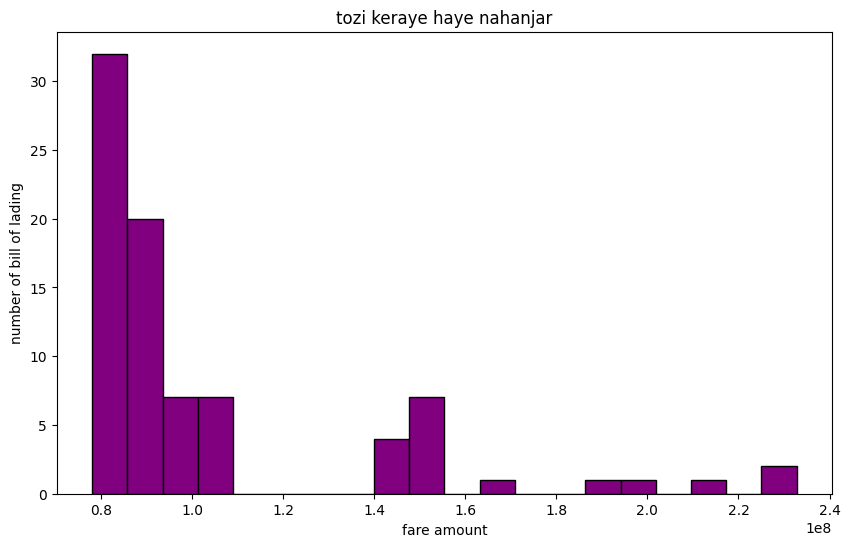

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
fare_anomalies['Calculation fare'].hist(bins=20, color='purple', edgecolor='black')
plt.title('tozi keraye haye nahanjar')
plt.xlabel('fare amount')
plt.ylabel('number of bill of lading')
plt.grid()
plt.show()

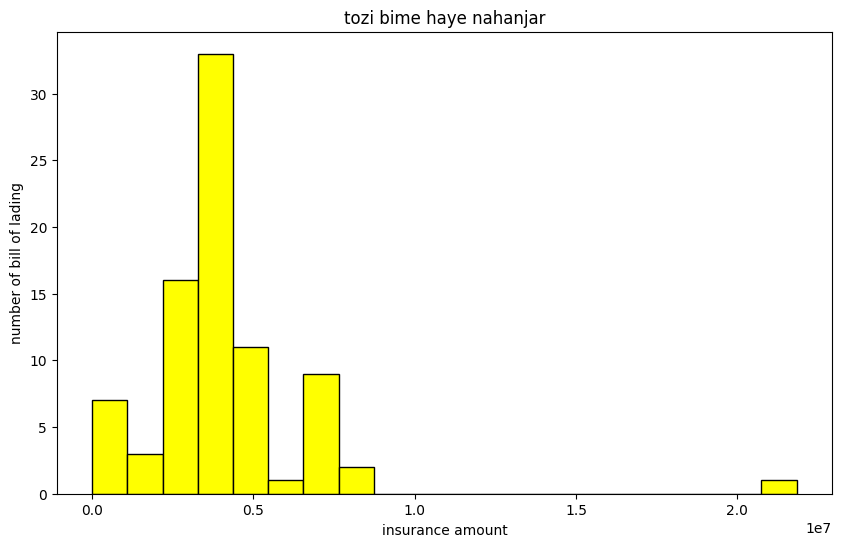

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
fare_anomalies['Insurance amount'].hist(bins=20, color='yellow', edgecolor='black')
plt.title('tozi bime haye nahanjar')
plt.xlabel('insurance amount')
plt.ylabel('number of bill of lading')
plt.grid()
plt.show()

In [ ]:
common_bills = set(fare_anomalies['Bill of lading number']) & set(insurance_anomalies['Bill of lading number'])
print("تعداد بارنامه با ناهنجار همزمان در بیمه و کرایه :", len(common_bills))
print(" شماره بارنامه ها: ", list(common_bills)[:])

تعداد بارنامه با ناهنجار همزمان در بیمه و کرایه : 2
 شماره بارنامه ها:  [7337925, 3399791]


In [ ]:
# (کرایه و بیمه)لیست بارنامه‌های ناهنجار مشترک
common_bills = list(set(fare_anomalies['Bill of lading number']) & set(insurance_anomalies['Bill of lading number']))
# استخراج ردیف‌ها از دیتافریم اصلی
common_rows = df[df['Bill of lading number'].isin(common_bills)]
common_rows[['Bill of lading number', 'Company name', 'Calculation fare','Insurance amount', 'Value added insurance premium', 'distance']]


,Bill of lading number,Company name,Calculation fare,Insurance amount,Value added insurance premium,distance
548047,7337925,قصربار قم,83036530,8250000,825000,148
574823,3399791,بين المللي هاگ بار,230000000,21840000,2184000,196


In [ ]:
print(common_rows['Company name'].unique())

['قصربار قم' 'بين المللي هاگ بار']


In [ ]:
# استخراج دو رکورد مورد نظر
common_rows = df[df['Bill of lading number'].isin(common_bills)].copy()

for col in ['Calculation fare', 'Value added insurance premium']:
    common_rows[col] = (
        common_rows[col].astype(str)
        .str.replace(',', '', regex=False)
        .str.strip()
        .replace(['', 'nan', 'NaN', 'None', '-', 'null'], '0')
        .astype(float)
    )

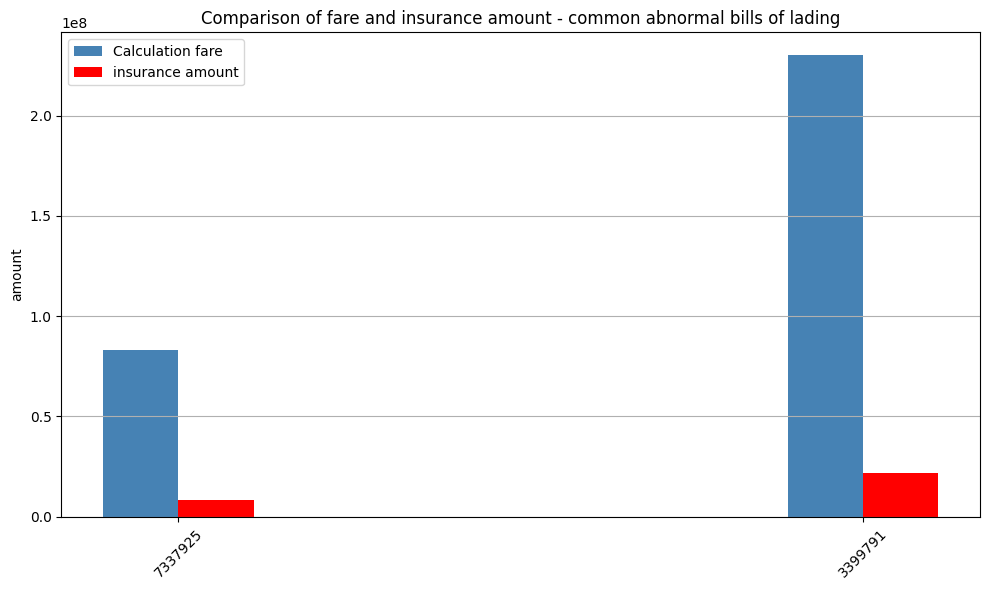

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = common_rows['Bill of lading number'].astype(str).tolist()
fares = common_rows['Calculation fare'].tolist()
insurances = common_rows['Insurance amount'].tolist()

x = np.arange(len(labels))
width = 0.11

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, fares, width, label='Calculation fare', color='steelblue')
plt.bar(x + width/2, insurances, width, label='insurance amount', color='red')

plt.ylabel('amount')
plt.title('Comparison of fare and insurance amount - common abnormal bills of lading')
plt.xticks(x, labels, rotation=45)
plt.legend()
plt.tight_layout()
plt.grid(True, axis='y')
plt.show()


__________________________________________________________

Kmeans Clustring

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


# فقط ستون‌های عددی مثل کرایه و بیمه
features = ['Calculation fare', 'Value added insurance premium']
df_cluster = df.dropna(subset=features).copy()

# تبدیل مقادیر به float و حذف , و ...
for col in features:
    df_cluster[col] = (
        df_cluster[col].astype(str)
        .str.replace(',', '', regex=False)
        .str.strip()
        .replace(['', 'nan', 'NaN', 'None', '-', 'null'], '0')
        .astype(float)
    )

# نرمال‌سازی
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[features])

# اجرای KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)
labels = kmeans.labels_


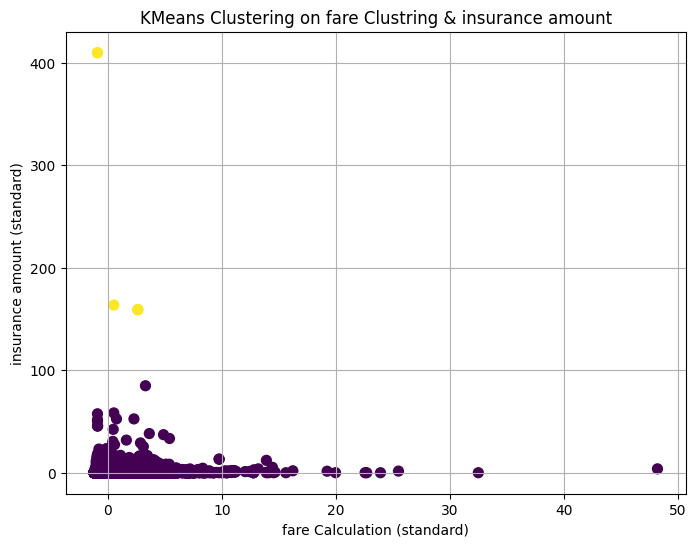

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', s=50)
plt.title('KMeans Clustering on fare Clustring & insurance amount')
plt.xlabel('fare Calculation (standard)')
plt.ylabel('insurance amount (standard)')
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
unique, counts = np.unique(labels, return_counts=True)
print(" تعداد رکورد در هر خوشه:")
for u, c in zip(unique, counts):
    print(f"خوشه {u}: {c} رکورد")

 تعداد رکورد در هر خوشه:
خوشه 0: 601211 رکورد
خوشه 1: 6 رکورد


In [ ]:
df_cluster['Cluster'] = labels
df_cluster.groupby(['Cluster', 'Company name'])['Calculation fare'].count()

Cluster  Company name                 
0        آباد تردد پارس                      5
         آبادان (اراک )                      2
         آبادان (قم )                     1347
         آبتين بار کوير شعبه سمنان           5
         آتشين ترابرهرمزگان                  1
                                          ... 
         گودرز گرگان (شعبه گنبد کاووس)       7
         گيشا ترابر                          3
         گيشاترابر جنوب                     10
1        روز بار قم                          3
         هما بار سلفچگان                     3
Name: Calculation fare, Length: 375, dtype: int64

In [ ]:
df_cluster[df_cluster['Cluster'] == 2]

,Value added insurance premium,Received from the driver,Scale fee,Evacuation fee,added value,Complications of moving goods,Bill of lading registration time,Tracking code watch,date of interception,Company commission,...,distance,weight,Calculation fare,rent,Bill of lading number,Bill of lading series,Company name,Company Code,year,Cluster


راه حل مشکل

In [ ]:
from scipy import stats
import numpy as np

# Z-Score
z_scores = np.abs(stats.zscore(X_scaled))
filtered_entries = (z_scores < 3).all(axis=1)
X_filtered = X_scaled[filtered_entries]

print("شکل داده بعد از حذف پرت‌ها:", X_filtered.shape)


شکل داده بعد از حذف پرت‌ها: (593410, 2)


In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_filtered)
labels = kmeans.labels_

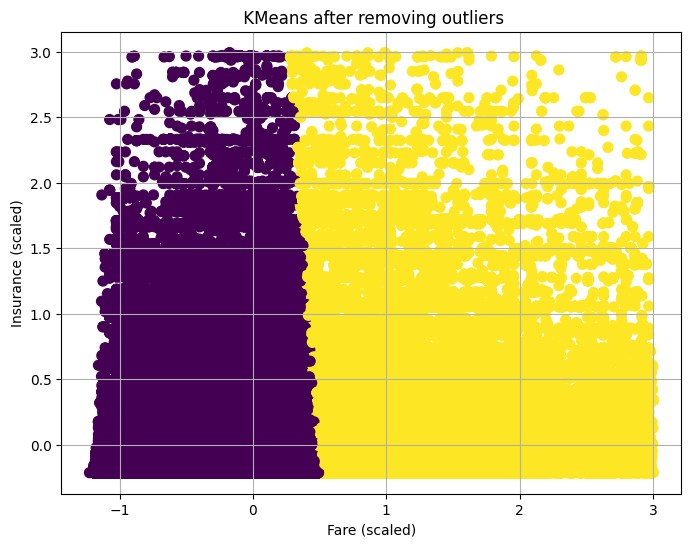

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_filtered[:, 0], X_filtered[:, 1], c=labels, cmap='viridis', s=50)
plt.title(' KMeans after removing outliers')
plt.xlabel('Fare (scaled)')
plt.ylabel('Insurance (scaled)')
plt.grid(True)
plt.show()

In [ ]:
df_cluster['Cluster'] = kmeans.labels_
df_cluster.groupby(['Cluster', 'Company name']).size()

In [ ]:
df_filtered = df_cluster[filtered_entries].copy()
df_filtered['Cluster'] = kmeans.labels_

In [ ]:
df_filtered.groupby(['Cluster', 'Company name']).size()

Cluster  Company name                 
0        آباد تردد پارس                      3
         آبادان (اراک )                      2
         آبادان (قم )                     1343
         آتشين ترابرهرمزگان                  1
         آتي ترابرخليج فارس                 91
                                          ... 
1        گودرز                              53
         گودرز (شعبه گرگان)                  2
         گودرز (شعبه گنبد کاووس)           115
         گودرز گرگان                        27
         گودرز گرگان (شعبه گنبد کاووس)       4
Length: 546, dtype: int64

In [ ]:
# دیتافریم فقط رکوردهای بدون پرت
df_filtered = df_cluster[filtered_entries].copy()

# اضافه کردن لیبل خوشه
df_filtered['Cluster'] = kmeans.labels_

In [ ]:
df_filtered.groupby(['Cluster', 'Company name']).size().sort_values(ascending=False)

Cluster  Company name      
0        توحيد راه سلفچگان     54492
         سعادت کوش قم          40015
         قصربار قم             31770
         شکوه بار مرکزي قم     28970
         امين ترابر            28300
                               ...  
         ارسلان بار سپاهان         1
         اتحاد شيراز               1
         اطلس بار بوشهر            1
         ارکان ترابر سيراف         1
1        پارس لجستيک پايتخت        1
Length: 546, dtype: int64

In [ ]:
df_filtered.groupby('Cluster')['Calculation fare'].mean()

,Calculation fare
Cluster,
0,4.767233e+07
1,1.571672e+08


In [ ]:
high_fare_cluster = 0

# فقط داده‌های این خوشه
high_fare_df = df_filtered[df_filtered['Cluster'] == high_fare_cluster]

# بررسی شرکت‌ها
top_companies = high_fare_df['Company name'].value_counts().head(10)
print(top_companies)


Company name
توحيد راه سلفچگان    54492
سعادت کوش قم         40015
قصربار قم            31770
شکوه بار مرکزي قم    28970
امين ترابر           28300
روز بار قم           22160
جاده ران گستر قم     21285
امان بار قم          20681
پرتو قم ترابر        20218
امين کشاورز (قم )    17485
Name: count, dtype: int64


In [ ]:
high_fare_df.groupby('Company name')['Calculation fare'].mean().sort_values(ascending=False).head(10)

,Calculation fare
Company name,
ارسلان ترابر يکتا,1.020300e+08
اطمينان باراشتهارد,1.000000e+08
قير مذاب پارس,1.000000e+08
مجتمع صنايع غذايي ميهن,9.836800e+07
رهنورد سيمان سپاهان,9.816900e+07
آريا پاد کاشان,9.800000e+07
توسعه لجستيک آداک,9.670024e+07
شرکت حمل و نقل توکا سير سپاهان,9.645000e+07
اراک رفاه,9.549612e+07


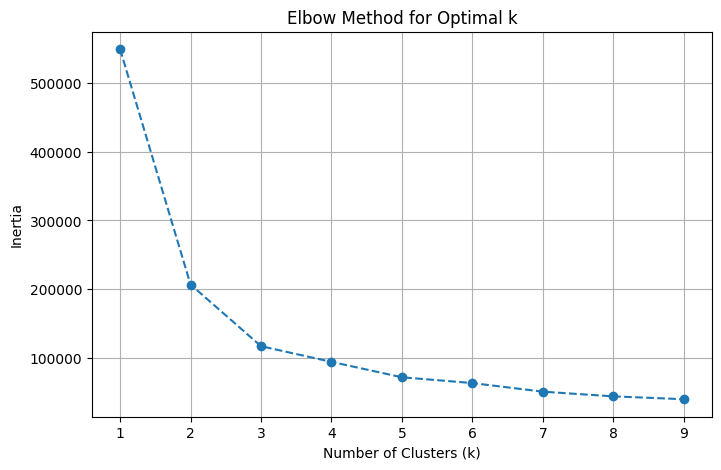

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []  # مجموع مربع فاصله نقاط از مرکز خوشه (معیار خطا SSE)
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_filtered)
    inertia.append(kmeans.inertia_)

# Elbow
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.xticks(K_range)
plt.show()

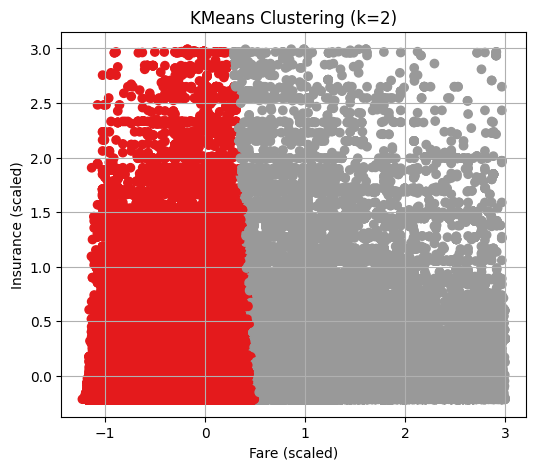

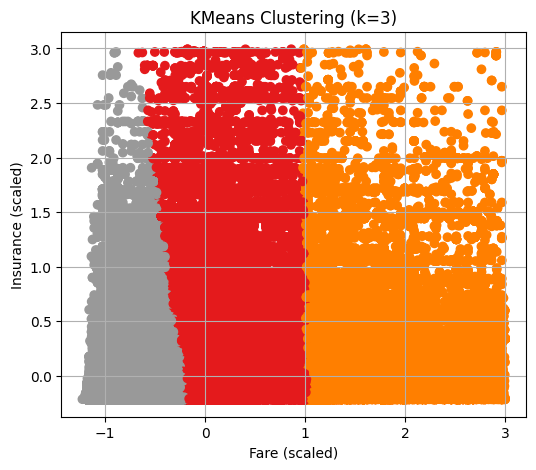

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

for k in [2, 3]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_filtered)
    labels = kmeans.labels_

    plt.figure(figsize=(6,5))
    plt.scatter(X_filtered[:,0], X_filtered[:,1], c=labels, cmap='Set1')
    plt.title(f'KMeans Clustering (k={k})')
    plt.xlabel('Fare (scaled)')
    plt.ylabel('Insurance (scaled)')
    plt.grid(True)
    plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

for k in [2, 3]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_filtered)
    score = silhouette_score(X_filtered, kmeans.labels_)
    print(f"k = {k}, Silhouette Score = {score:.4f}")